<a href="https://colab.research.google.com/github/ayyucedemirbas/Genome_Comparison/blob/main/Nymphicus_hollandicus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 20.3 MB/s eta 0:00:00


In [2]:
import matplotlib.pyplot as plt
from collections import Counter
from Bio import SeqIO
import time

In [4]:
fasta_file = "/content/drive/MyDrive/cockatiel_ncbi_dataset/ncbi_dataset/data/GCA_009823435.2/GCA_009823435.2_ASM982343v2_genomic.fna"
k = 4
kmer_counts = Counter()
start_time = time.time()

record_count = 0

In [ ]:
for record in SeqIO.parse(fasta_file, "fasta"):
  sequence = str(record.seq).upper()
  for i in range(len(sequence) - k + 1):
    kmer = sequence[i:i+k]
    if "N" not in kmer:
      kmer_counts[kmer] += 1
  record_count += 1
  if record_count % 100 == 0:
    print(f"Record {record_count} ({record.id})")

In [6]:
end_time = time.time()
print(f"Elapsed time: {round(end_time - start_time, 2)} seconds.")

Elapsed time: 868.98 seconds.


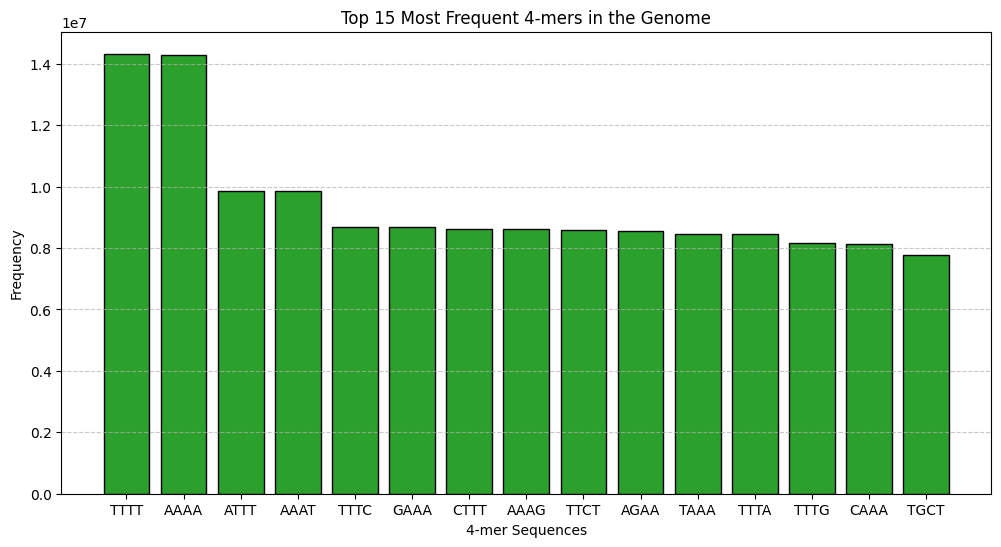

In [7]:
top_15_kmers = kmer_counts.most_common(15)

if top_15_kmers:
    kmers, counts = zip(*top_15_kmers)
    plt.figure(figsize=(12, 6))
    plt.bar(kmers, counts, color='#2ca02c', edgecolor='black')
    plt.title(f"Top 15 Most Frequent {k}-mers in the Genome")
    plt.xlabel(f"{k}-mer Sequences")
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()
else:
    print("No valid k-mers were found. Ensure the dataset contains valid nucleotide sequences.")

In [ ]:
"""import os
target_folder = '/content/drive/MyDrive/Chicken_Genome'
os.makedirs(target_folder, exist_ok=True)

%cd {target_folder}

api_url = "https://api.ncbi.nlm.nih.gov/datasets/v2/genome/accession/GCF_016699485.2/download?include_annotation_type=GENOME_FASTA&include_annotation_type=GENOME_GFF&include_annotation_type=RNA_FASTA&include_annotation_type=CDS_FASTA&include_annotation_type=PROT_FASTA&include_annotation_type=SEQUENCE_REPORT&hydrated=FULLY_HYDRATED"

!wget "{api_url}" -O chicken_genome.zip

!unzip -q chicken_genome.zip"""

In [8]:
fasta_file = "/content/drive/MyDrive/Chicken_Genome/ncbi_dataset/data/GCF_016699485.2/GCF_016699485.2_bGalGal1.mat.broiler.GRCg7b_genomic.fna"
kmer_counts = Counter()
record_count = 0

In [9]:
for record in SeqIO.parse(fasta_file, "fasta"):
  sequence = str(record.seq).upper()
  for i in range(len(sequence) - k + 1):
    kmer = sequence[i:i+k]
    if "N" not in kmer:
      kmer_counts[kmer] += 1
  record_count += 1
  if record_count % 1000 == 0:
    print(f"Record {record_count} ({record.id})")

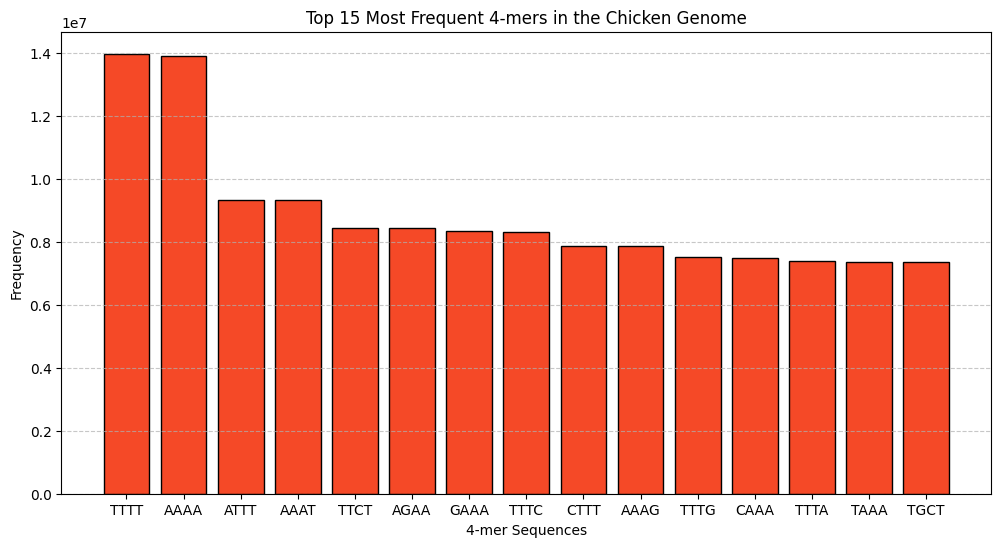

In [10]:
top_15_kmers = kmer_counts.most_common(15)

if top_15_kmers:
    kmers, counts = zip(*top_15_kmers)
    plt.figure(figsize=(12, 6))
    plt.bar(kmers, counts, color='#F54927', edgecolor='black')
    plt.title(f"Top 15 Most Frequent {k}-mers in the Chicken Genome")
    plt.xlabel(f"{k}-mer Sequences")
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()
else:
    print("No valid k-mers were found. Ensure the dataset contains valid nucleotide sequences.")

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [12]:
parrot_file = "/content/drive/MyDrive/cockatiel_ncbi_dataset/ncbi_dataset/data/GCA_009823435.2/GCA_009823435.2_ASM982343v2_genomic.fna"
chicken_file = "/content/drive/MyDrive/Chicken_Genome/ncbi_dataset/data/GCF_016699485.2/GCF_016699485.2_bGalGal1.mat.broiler.GRCg7b_genomic.fna"
K = 4
CHUNK_SIZE = 100000
MAX_CHUNKS = 200


In [13]:
def extract_kmer_features(fasta_path, species_label, k, chunk_size, max_chunks):
    data = []
    current_chunk = ""
    chunk_count = 0
    try:
        for record in SeqIO.parse(fasta_path, "fasta"):
            if chunk_count >= max_chunks:
                break

            sequence = str(record.seq).upper()
            current_chunk += sequence

            while len(current_chunk) >= chunk_size and chunk_count < max_chunks:
                chunk_seq = current_chunk[:chunk_size]
                current_chunk = current_chunk[chunk_size:]

                kmer_counts = Counter()
                for i in range(len(chunk_seq) - k + 1):
                    kmer = chunk_seq[i:i+k]
                    if "N" not in kmer:
                        kmer_counts[kmer] += 1

                kmer_counts['Species'] = species_label
                data.append(kmer_counts)
                chunk_count += 1

                if chunk_count % 50 == 0:
                    print(f"  Extracted {chunk_count}/{max_chunks} samples")

    except Exception as e:
         print(f"Error processing {species_label}: {e}")

    return data

In [14]:
parrot_data = extract_kmer_features(parrot_file, "Cockatiel (Parrot)", K, CHUNK_SIZE, MAX_CHUNKS)
chicken_data = extract_kmer_features(chicken_file, "Chicken (Control)", K, CHUNK_SIZE, MAX_CHUNKS)

  Extracted 50/200 samples
  Extracted 100/200 samples
  Extracted 150/200 samples
  Extracted 200/200 samples
  Extracted 50/200 samples
  Extracted 100/200 samples
  Extracted 150/200 samples
  Extracted 200/200 samples


In [15]:
df = pd.DataFrame(parrot_data + chicken_data)
df = df.fillna(0)

In [16]:
df.shape[0]

400

In [17]:
df.shape[1]-1

256

In [18]:
X = df.drop('Species', axis=1)
y = df['Species']

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Species'] = y.values

explained_variance = pca.explained_variance_ratio_ * 100

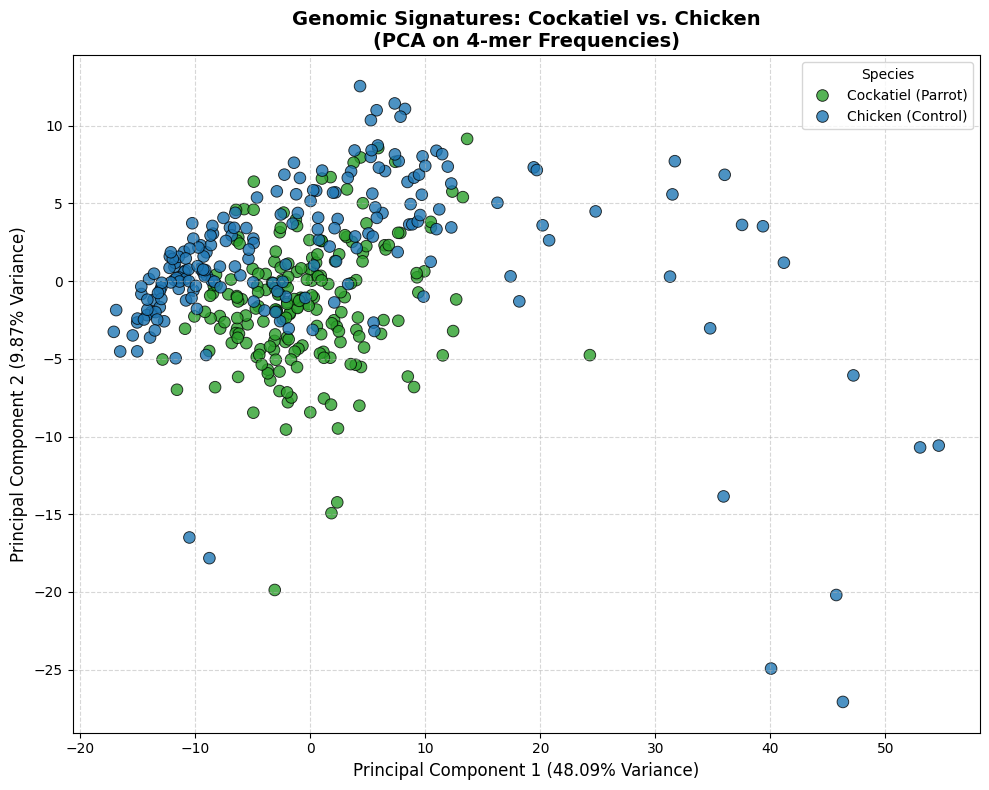

In [29]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Species',
    palette=['#2ca02c', '#1f77b4'],
    data=pca_df,
    s=70,
    alpha=0.8,
    edgecolor='k'
)

plt.title('Genomic Signatures: Cockatiel vs. Chicken\n(PCA on 4-mer Frequencies)', fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.2f}% Variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.2f}% Variance)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Species', loc='best')
plt.tight_layout()
plt.show()

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [25]:
predictions = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

In [26]:
accuracy * 100

95.0

In [27]:
importances = rf_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({
    '4-mer Sequence': feature_names,
    'Importance Score': importances
})


/tmp/ipykernel_6971/2991682147.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


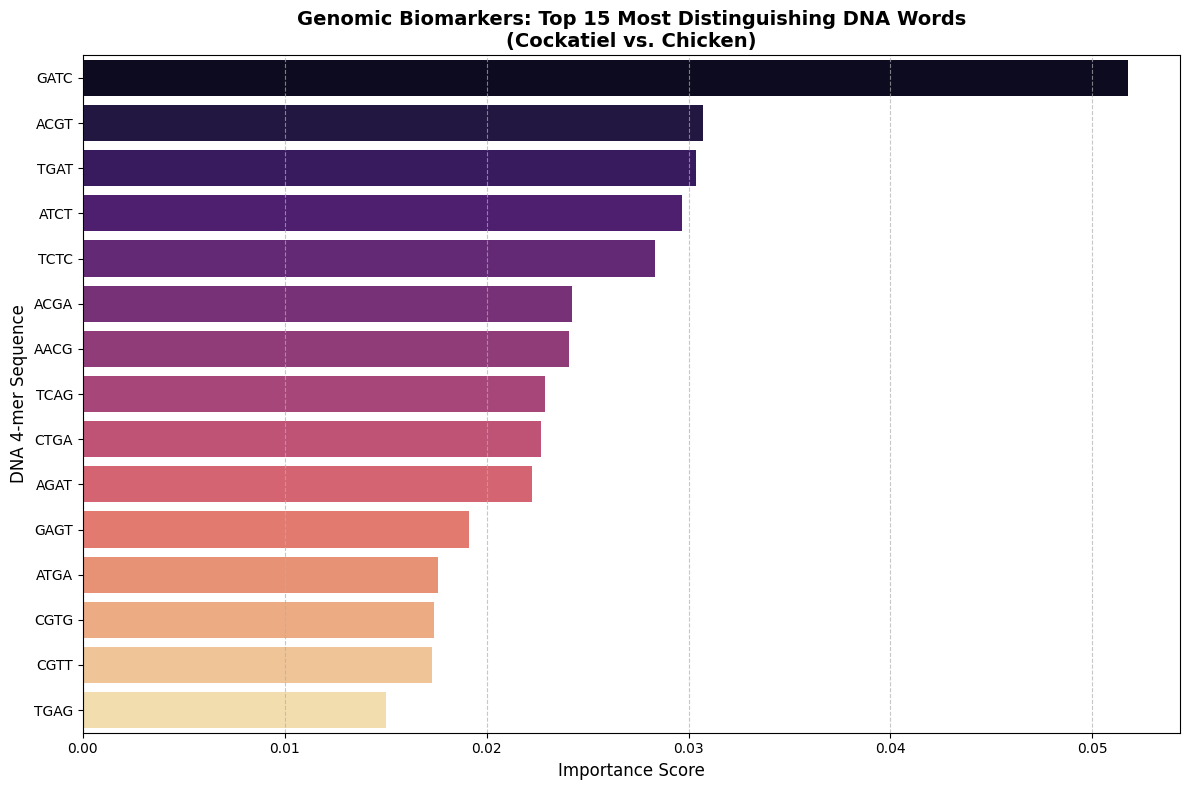

In [28]:
top_15_features = importance_df.sort_values(by='Importance Score', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance Score',
    y='4-mer Sequence',
    data=top_15_features,
    palette='magma'
)

plt.title("Genomic Biomarkers: Top 15 Most Distinguishing DNA Words\n(Cockatiel vs. Chicken)", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("DNA 4-mer Sequence", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [32]:
fasta_file = "/content/drive/MyDrive/cockatiel_ncbi_dataset/ncbi_dataset/data/GCA_009823435.2/GCA_009823435.2_ASM982343v2_genomic.fna"

TARGET_MOTIF = "GATC"
WINDOW_SIZE = 1000

max_count = 0
best_sequence = ""
best_location = ""
chunks_processed = 0

try:
    for record in SeqIO.parse(fasta_file, "fasta"):
        seq = str(record.seq).upper()

        for i in range(0, len(seq) - WINDOW_SIZE + 1, WINDOW_SIZE):
            chunk = seq[i:i+WINDOW_SIZE]
            if chunk.count("N") > 100:
                continue

            count = chunk.count(TARGET_MOTIF)
            chunks_processed += 1

            if count > max_count:
                max_count = count
                best_sequence = chunk
                best_location = f"Chromosome: {record.id}, Coordinate: {i} - {i+WINDOW_SIZE}"

except FileNotFoundError:
    print("File not found")
    raise

print(f"{chunks_processed}")
print(f"{best_location}")
print(f"{max_count}")


1026072
Chromosome: WTXV02023518.1, Coordinate: 4000 - 5000
94


In [33]:
print(best_sequence)

GGGATCGGGATCAATGGGATCAATGGGATCGGGATCATTCGGTTCAATGGGATCACCATCGGGATCAATGGGATCACCATCGGGATCAATGGGATCGGGATCAATGGCATCGGGATCAATGGCATCGGGATCAATGGCATCGGGATCAATGGGATCACCATCAGGATCAATGGGATCGGGATCAATGGGATCGGGATCAATGGGATCACCATCGGGATCAATGGGATCGGGATCAATGGGACCAGGATCGGGATCAATGGGATCACCATTGGGATCAATGGGATCGGGATCAATGGGATCATCATTGGGATCAATGGGATCACCATTGGGATCAATGGGATCGGGATAGGGATCATTGGGTTCAATGGGATTGGGATTGGGATCAATGGGATCATCATTGGGATCATCATCGGGATCAATGGGATTGGGATCATTGGGATCAATGGGATCAGGATTGGGATCAATGGGATCATCATTGGGATCATTGGGATCAATGGGATCGGGATCATTGGGATCATCGGGATCATTGGGATCATCATCGGGATCAATGGGATCGGGATCAATGGGATCAGGATCGGGATCAATGGGATCATCATTGGGATCAATGGGATCAATGGGATCAGGATCGGGATCATTGGGATCAATGGGATCATCATCGAGATCATTGGGATTATCATTGGGATCAATGGGATCATCATTGGGATCAATGGGTTCAATGGGATCGGGATCAATGGGATCATCATTGGGATCATTGGGATCATCATTGGGATCATTGGGTTCAATGGGATCGGGATCATTGGGATCATTGGGATCATCATTGGGATCAATGGGATCATCATCGGGATCATCGGGATCAATGGGATCGGGATCGGGATCATTGGGATCAATGGGATCGGGATCGGGATCAATGGGATCATCATTGGGATCACTGGGATGGATCCGGAGGGGGTTTTCCCTCCCTATGGGAATGCCGTAGATGGAGCGGGAGATGAGGCACAAG